In [ ]:
pip install qiskit

In [ ]:
pip install qiskit-ibm-runtime

In [ ]:
pip install qiskit-aer

In [ ]:
pip install qiskit-algorithms

In [ ]:
pip install rustworkx

In [86]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
from qiskit.circuit.library import QAOAAnsatz
from scipy.optimize import minimize
from qiskit.primitives import StatevectorEstimator, Estimator, Sampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt

## Generar grafo ejemplo con 5 nodos

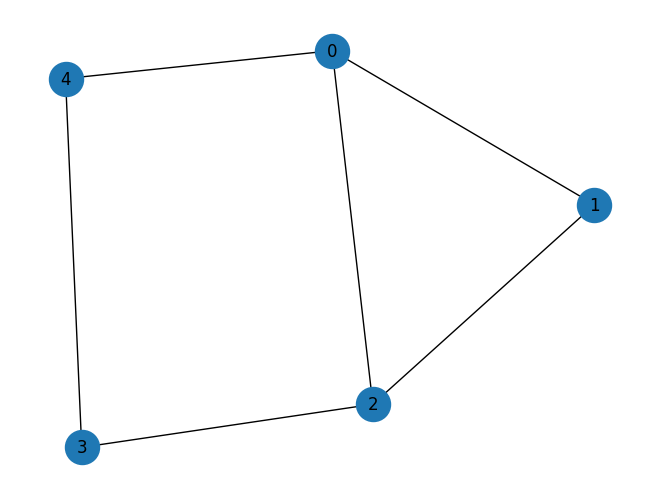

In [6]:
#- Generar grafo de 5 nodos
n = 5 # Numero de nodos.
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1)) # Nodos del grafo.
edge_list = [(0, 1, 1.0), (0, 2, 1.0), (0, 4, 1.0), (1, 2, 1.0), (2, 3, 1.0), (3, 4, 1.0)] # Conexiones del grafo.
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

## Convertir grafo en Hamiltoniano (Operador de Fase)

In [8]:
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    # Convertimos el grafo en una cadena de operadores de Pauli (Z e I).
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("".join(paulis)[::-1], weight))
    return pauli_list

In [12]:
max_cut_paulis = build_max_cut_paulis(graph)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Hamiltoniano de costo (Operador de fase):", cost_hamiltonian)

Hamiltoniano de costo (Operador de fase): SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


## Generar QAOA usando qiskit QAOA-Ansatz (built-in method)



In [15]:
#- Generar circuit usando nuestro problema codificado como cadenas de Pauli.
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
#- Medición en las salidas del circuito.
circuit.measure_all()
circuit.draw()

┌────────────────────────────┐ ░ ┌─┐            
   q_0: ┤0                           ├─░─┤M├────────────
        │                            │ ░ └╥┘┌─┐         
   q_1: ┤1                           ├─░──╫─┤M├─────────
        │                            │ ░  ║ └╥┘┌─┐      
   q_2: ┤2 QAOA(γ[0],β[0],γ[1],β[1]) ├─░──╫──╫─┤M├──────
        │                            │ ░  ║  ║ └╥┘┌─┐   
   q_3: ┤3                           ├─░──╫──╫──╫─┤M├───
        │                            │ ░  ║  ║  ║ └╥┘┌─┐
   q_4: ┤4                           ├─░──╫──╫──╫──╫─┤M├
        └────────────────────────────┘ ░  ║  ║  ║  ║ └╥┘
meas: 5/══════════════════════════════════╩══╩══╩══╩══╩═
                                          0  1  2  3  4

In [16]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

## Optimización de QAOA

In [78]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Crear un circuito pre-transpilado.
pm = generate_preset_pass_manager(optimization_level=3)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw(fold=False, idle_wires=False)

┌───┐                                                            »
   q_0: ┤ H ├─■──────────────■─────────────────────────────■─────────────»
        ├───┤ │ZZ(2.0*γ[0])  │                             │             »
   q_1: ┤ H ├─■──────────────┼──────────────■──────────────┼─────────────»
        ├───┤                │ZZ(2.0*γ[0])  │ZZ(2.0*γ[0])  │             »
   q_2: ┤ H ├────────────────■──────────────■──────────────┼─────────────»
        ├───┤                                              │             »
   q_3: ┤ H ├──────────────────────────────────────────────┼─────────────»
        ├───┤                                              │ZZ(2.0*γ[0]) »
   q_4: ┤ H ├──────────────────────────────────────────────■─────────────»
        └───┘                                                            »
meas: 5/═════════════════════════════════════════════════════════════════»
                                                                         »
«        ┌──────────────┐                                               »
«   q_0: ┤ Rx(2.0*β[0]) ├─■───────────────■─────────────────────────────»
«        ├──────────────┤ │ZZ(2.0*γ[1])   │                             »
«   q_1: ┤ Rx(2.0*β[0]) ├─■───────────────┼───────────────■─────────────»
«        └──────────────┘┌──────────────┐ │ZZ(2.0*γ[1])   │ZZ(2.0*γ[1]) »
«   q_2: ─■──────────────┤ Rx(2.0*β[0]) ├─■───────────────■─────────────»
«         │ZZ(2.0*γ[0])  └──────────────┘┌──────────────┐               »
«   q_3: ─■───────────────■──────────────┤ Rx(2.0*β[0]) ├───────────────»
«                         │ZZ(2.0*γ[0])  ├──────────────┤               »
«   q_4: ─────────────────■──────────────┤ Rx(2.0*β[0]) ├───────────────»
«                                        └──────────────┘               »
«meas: 5/═══════════════════════════════════════════════════════════════»
«                                                                       »
«                       ┌──────────────┐                                 ░ ┌─┐»
«   q_0: ─■─────────────┤ Rx(2.0*β[1]) ├─────────────────────────────────░─┤M├»
«         │             ├──────────────┤                                 ░ └╥┘»
«   q_1: ─┼─────────────┤ Rx(2.0*β[1]) ├─────────────────────────────────░──╫─»
«         │             └──────────────┘┌──────────────┐                 ░  ║ »
«   q_2: ─┼──────────────■──────────────┤ Rx(2.0*β[1]) ├─────────────────░──╫─»
«         │              │ZZ(2.0*γ[1])  └──────────────┘┌──────────────┐ ░  ║ »
«   q_3: ─┼──────────────■───────────────■──────────────┤ Rx(2.0*β[1]) ├─░──╫─»
«         │ZZ(2.0*γ[1])                  │ZZ(2.0*γ[1])  ├──────────────┤ ░  ║ »
«   q_4: ─■──────────────────────────────■──────────────┤ Rx(2.0*β[1]) ├─░──╫─»
«                                                       └──────────────┘ ░  ║ »
«meas: 5/═══════════════════════════════════════════════════════════════════╩═»
«                                                                           0 »
«                    
«   q_0: ────────────
«        ┌─┐         
«   q_1: ┤M├─────────
«        └╥┘┌─┐      
«   q_2: ─╫─┤M├──────
«         ║ └╥┘┌─┐   
«   q_3: ─╫──╫─┤M├───
«         ║  ║ └╥┘┌─┐
«   q_4: ─╫──╫──╫─┤M├
«         ║  ║  ║ └╥┘
«meas: 5/═╩══╩══╩══╩═
«         1  2  3  4

In [79]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # Funcion para calcular la función de costo.
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)
    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])
    results = job.result()[0]
    cost = results.data.evs
    objective_func_vals.append(cost)

    return cost

In [84]:
objective_func_vals = []
initial_gamma = np.pi
initial_beta = np.pi/2
init_params = [initial_gamma, initial_beta, initial_gamma, initial_beta]

# Generamos un estimadorV2 que usa AerSimulator, el emulador de computadora cuántica real.
estimator = EstimatorV2()
estimator.options.default_shots = 1000

# Usamos un min
result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, cost_hamiltonian, estimator),
    method="COBYLA",
    tol=1e-2,
)
print(result)

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -1.015625
       x: [ 3.588e+00  1.551e+00  4.194e+00  9.614e-01]
    nfev: 31
   maxcv: 0.0


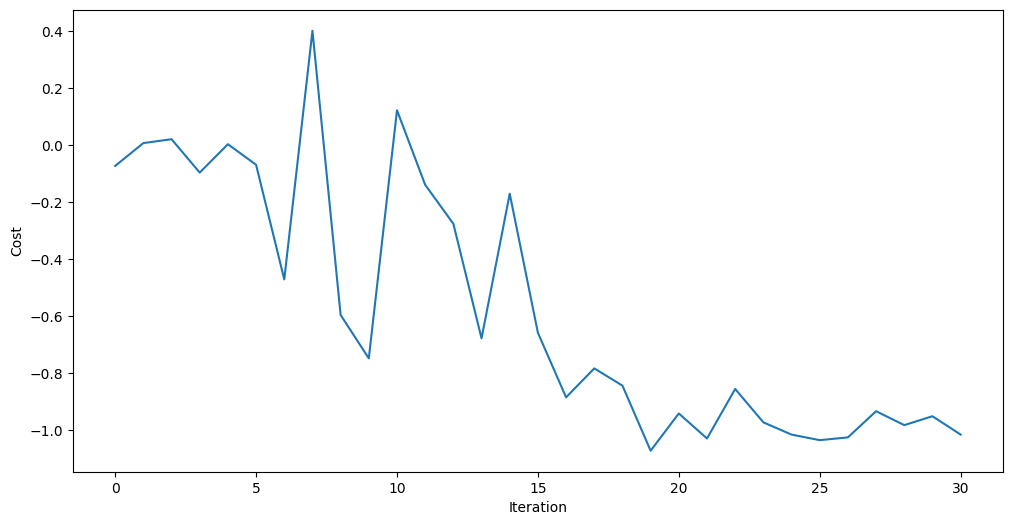

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

## Otra manera de hacerlo usando QAOA (built-in function)

In [88]:
sampler = Sampler()

optimizer = COBYLA()
qaoa = QAOA(sampler, optimizer, reps=2)

result = qaoa.compute_minimum_eigenvalue(cost_hamiltonian)
print(result)

<ipython-input-88-1935a443a754>:1: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler()


{   'aux_operators_evaluated': None,
    'best_measurement': {   'bitstring': '01001',
                            'probability': 0.1082372659180222,
                            'state': 9,
                            'value': (-4+0j)},
    'cost_function_evals': 72,
    'eigenstate': {0: 0.0016881047376, 1: 0.0084397656635, 2: 0.004562283303421, 3: 0.006789281386634, 4: 0.0084397656635, 5: 0.082942430717629, 6: 0.006789281386634, 7: 0.003301865654423, 8: 0.000366391890447, 9: 0.10560311228927, 10: 0.048096386728417, 11: 0.10560311228927, 12: 0.034457719835194, 13: 0.048096386728417, 14: 0.034457719835194, 15: 0.000366391890447, 16: 0.000366391890447, 17: 0.034457719835194, 18: 0.048096386728417, 19: 0.034457719835194, 20: 0.10560311228927, 21: 0.048096386728417, 22: 0.10560311228927, 23: 0.000366391890447, 24: 0.003301865654423, 25: 0.006789281386634, 26: 0.082942430717629, 27: 0.0084397656635, 28: 0.006789281386634, 29: 0.004562283303421, 30: 0.0084397656635, 31: 0.0016881047376},
  

In [58]:
best_measurement = result.best_measurement
print(best_measurement)

{'state': 9, 'bitstring': '01001', 'value': (-4+0j), 'probability': 0.0450366265944026}
